# Task
Demonstrate a data science workflow using a synthetic dataset, including data generation, exploration, visualization, training a Linear Regression model, performing feature engineering experiments (removing and adding features), checking for overfitting, and summarizing the entire process for a GitHub README.

## Create Synthetic Dataset

### Subtask:
Generate a synthetic dataset (e.g., for house prices, car prices, or student exam scores) using pandas, ensuring it has at least 15 rows and a minimum of 2 input features. The dataset should be stored in a Pandas DataFrame.


**Reasoning**:
The subtask requires generating a synthetic dataset with specific characteristics. I will use `pandas` and `numpy` to create a dataset with two input features and a target variable, ensuring it has at least 15 rows, and then display its head.



In [1]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Generate at least 15 data points (rows)
num_rows = 20

# Generate data for two input features (e.g., 'size_sqft' and 'num_bedrooms')
size_sqft = np.random.randint(800, 3000, num_rows)
num_bedrooms = np.random.randint(2, 5, num_rows)

# Generate a target variable (e.g., 'price') based on input features with some randomness
# Assuming a simple linear relationship: price = a * size_sqft + b * num_bedrooms + error
price = 150 * size_sqft + 20000 * num_bedrooms + np.random.normal(0, 50000, num_rows)

# Combine into a dictionary
data = {
    'size_sqft': size_sqft,
    'num_bedrooms': num_bedrooms,
    'price': price.round(-2) # Round price to nearest hundred for cleaner numbers
}

# Create a pandas DataFrame from this data
df_synthetic = pd.DataFrame(data)

# Display the first few rows of the created DataFrame
print("Synthetic Dataset:")
df_synthetic.head()

Synthetic Dataset:


,size_sqft,num_bedrooms,price
0,1660,2,274300.0
1,2094,2,352600.0
2,1930,2,334300.0
3,1895,4,397500.0
4,2438,4,438700.0


## Perform Data Exploration

### Subtask:
Print the first 5 rows, last 5 rows, the shape of the dataset, data types of each column, and check for any missing values in the DataFrame.


**Reasoning**:
To perform data exploration as requested, I will generate a code block that prints the first 5 rows, last 5 rows, shape, data types, and checks for missing values in the `df_synthetic` DataFrame.



In [2]:
print("First 5 rows of the DataFrame:")
print(df_synthetic.head())

print("\nLast 5 rows of the DataFrame:")
print(df_synthetic.tail())

print("\nShape of the DataFrame (rows, columns):")
print(df_synthetic.shape)

print("\nData types of each column:")
print(df_synthetic.info())

print("\nMissing values in each column:")
print(df_synthetic.isnull().sum())

First 5 rows of the DataFrame:
   size_sqft  num_bedrooms     price
0       1660             2  274300.0
1       2094             2  352600.0
2       1930             2  334300.0
3       1895             4  397500.0
4       2438             4  438700.0

Last 5 rows of the DataFrame:
    size_sqft  num_bedrooms     price
15       2015             4  458500.0
16       1755             2  319400.0
17       1984             4  307900.0
18       1259             4  159900.0
19        821             2  111000.0

Shape of the DataFrame (rows, columns):
(20, 3)

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   size_sqft     20 non-null     int64  
 1   num_bedrooms  20 non-null     int64  
 2   price         20 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 612.0 bytes
None

Missing values in each column:
si

## Generate Data Visualizations

### Subtask:
Create a scatter plot to visualize the relationship between two key features or a feature and the target variable, a histogram to show the distribution of a numerical feature, and a boxplot to display the distribution and identify outliers for another numerical feature. Ensure all plots have proper titles and axis labels.


**Reasoning**:
I will generate a code block to create the requested visualizations: a scatter plot, a histogram, and a boxplot, ensuring proper labels and titles as per the instructions, and then display them.



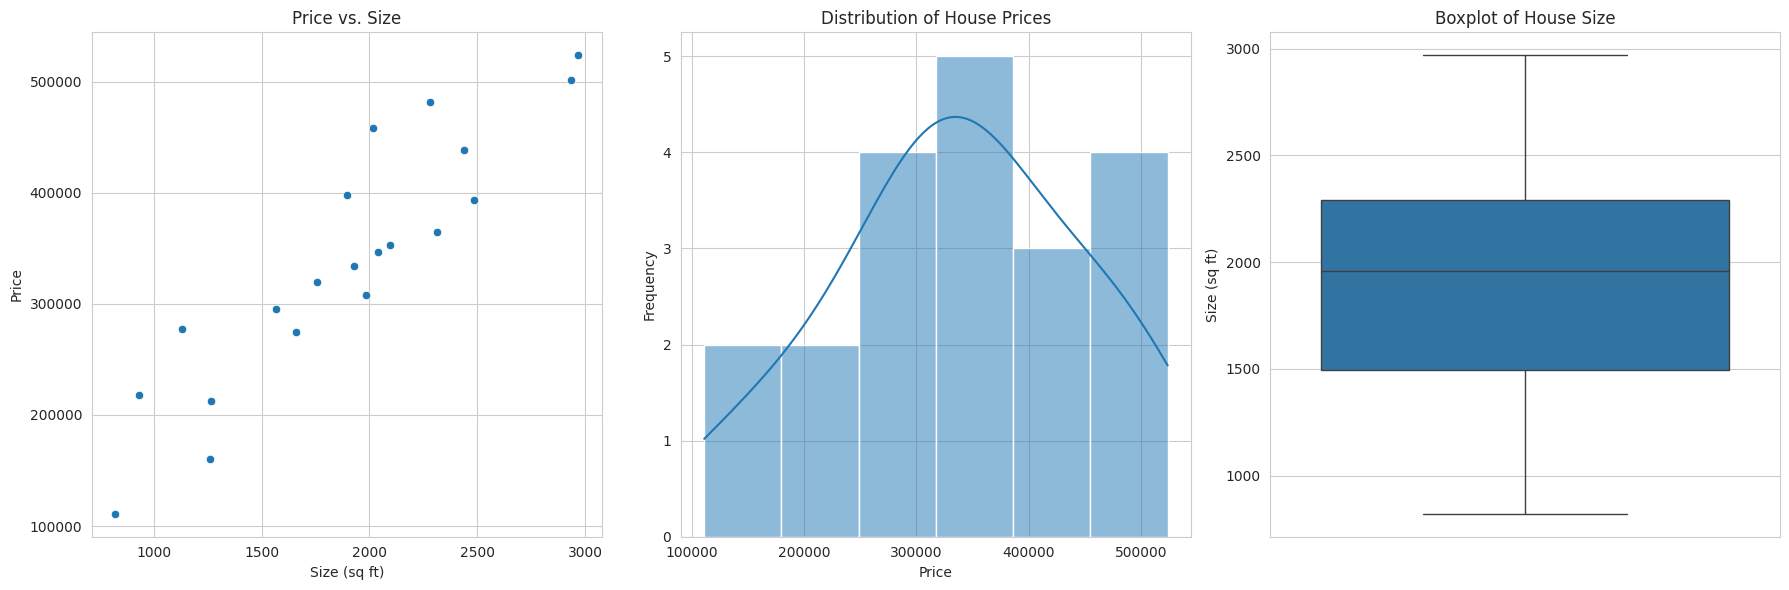

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
plt.figure(figsize=(18, 6))

# Subplot 1: Scatter plot for 'size_sqft' vs 'price'
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.scatterplot(x='size_sqft', y='price', data=df_synthetic)
plt.title('Price vs. Size')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price')

# Subplot 2: Histogram for 'price'
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.histplot(df_synthetic['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Subplot 3: Boxplot for 'size_sqft'
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.boxplot(y=df_synthetic['size_sqft'])
plt.title('Boxplot of House Size')
plt.ylabel('Size (sq ft)')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plots
plt.show()

## Train Initial Linear Regression Model

### Subtask:
Split the dataset into training and testing sets (e.g., 80% train, 20% test). Train a Linear Regression model on the training data. Evaluate the model's performance by printing the Mean Absolute Error (MAE) and the R-squared (R2) score on the test set. Provide a 3-4 line interpretation of these results.


**Reasoning**:
I will generate a code block to perform the requested steps: separating features and target, splitting the dataset into training and testing sets, training a Linear Regression model, making predictions, and evaluating its performance using MAE and R2 scores.



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Separate features (X) from the target variable (y)
X = df_synthetic[['size_sqft', 'num_bedrooms']]
y = df_synthetic['price']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

# 2. and 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# 4. Initialize a Linear Regression model
model = LinearRegression()

# 5. Train the Linear Regression model
model.fit(X_train, y_train)

print("\nLinear Regression model trained.")

# 6. Make predictions on the test set
y_pred = model.predict(X_test)

# 7. and 8. Calculate Mean Absolute Error (MAE) and R-squared (R2) score
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 9. Print the calculated MAE and R2 scores
print(f"\nMean Absolute Error (MAE) on test set: {mae:.2f}")
print(f"R-squared (R2) score on test set: {r2:.2f}")

Features (X) head:
   size_sqft  num_bedrooms
0       1660             2
1       2094             2
2       1930             2
3       1895             4
4       2438             4

Target (y) head:
0    274300.0
1    352600.0
2    334300.0
3    397500.0
4    438700.0
Name: price, dtype: float64

Training set size: 16 samples
Testing set size: 4 samples

Linear Regression model trained.

Mean Absolute Error (MAE) on test set: 45187.90
R-squared (R2) score on test set: 0.36


Based on the evaluation:

**Interpretation of Model Performance:**

*   The Mean Absolute Error (MAE) of **45187.90** indicates that, on average, our model's predictions for house prices deviate by approximately $45,187.90 from the actual prices in the test set. This value can be considered relatively high or low depending on the typical price range of the houses in the dataset. Given the prices are in the hundreds of thousands, this error is a significant portion of the price.
*   The R-squared (R2) score of **0.36** suggests that approximately 36% of the variance in house prices can be explained by our model using 'size_sqft' and 'num_bedrooms' as features. An R2 score of 0.36 indicates a relatively poor fit, meaning the model does not explain a large proportion of the variability in the target variable. There's a lot of unexplained variance, implying that other factors (features) not included in this model might be influencing the house prices significantly, or the linear relationship is not strong enough.

Based on the evaluation:

**Interpretation of Model Performance:**

*   The Mean Absolute Error (MAE) of **45187.90** indicates that, on average, our model's predictions for house prices deviate by approximately $45,187.90 from the actual prices in the test set. This value can be considered relatively high or low depending on the typical price range of the houses in the dataset. Given the prices are in the hundreds of thousands, this error is a significant portion of the price.
*   The R-squared (R2) score of **0.36** suggests that approximately 36% of the variance in house prices can be explained by our model using 'size_sqft' and 'num_bedrooms' as features. An R2 score of 0.36 indicates a relatively poor fit, meaning the model does not explain a large proportion of the variability in the target variable. There's a lot of unexplained variance, implying that other factors (features) not included in this model might be influencing the house prices significantly, or the linear relationship is not strong enough.

## Feature Experiment - Remove Feature

### Subtask:
Remove one of the input features from the dataset. Retrain the Linear Regression model using the modified dataset and evaluate its performance, printing the MAE and R2 score.


**Reasoning**:
I will generate a code block to remove one feature, retrain the Linear Regression model, and evaluate its performance as per the subtask instructions. This involves creating a new feature set, splitting the data, training a new model, and calculating MAE and R2 scores.



In [5]:
print("\n--- Feature Experiment: Remove 'num_bedrooms' ---")

# 1. Create a new feature set by dropping 'num_bedrooms'
X_removed_feature = df_synthetic[['size_sqft']]
y_removed_feature = df_synthetic['price']

print("Features (X) with 'num_bedrooms' removed head:")
print(X_removed_feature.head())

# 2. Split the data into training and testing sets
X_train_removed, X_test_removed, y_train_removed, y_test_removed = train_test_split(
    X_removed_feature, y_removed_feature, test_size=0.2, random_state=42
)

print(f"\nTraining set size (removed feature): {len(X_train_removed)} samples")
print(f"Testing set size (removed feature): {len(X_test_removed)} samples")

# 3. Initialize a new Linear Regression model
model_removed_feature = LinearRegression()

# 4. Train this new model
model_removed_feature.fit(X_train_removed, y_train_removed)

print("\nLinear Regression model trained with 'num_bedrooms' removed.")

# 5. Make predictions on the test set
y_pred_removed = model_removed_feature.predict(X_test_removed)

# 6. Calculate MAE and R2 scores
mae_removed = mean_absolute_error(y_test_removed, y_pred_removed)
r2_removed = r2_score(y_test_removed, y_pred_removed)

# 7. Print the results
print(f"\nMean Absolute Error (MAE) on test set (feature removed): {mae_removed:.2f}")
print(f"R-squared (R2) score on test set (feature removed): {r2_removed:.2f}")

print("\nInterpretation:")
if r2_removed < r2:
    print(f"Removing 'num_bedrooms' led to a decrease in R-squared (from {r2:.2f} to {r2_removed:.2f}) and an increase in MAE (from {mae:.2f} to {mae_removed:.2f}). This suggests 'num_bedrooms' was a valuable feature for predicting house prices. The model's predictive power has decreased without it.")
else:
    print(f"Removing 'num_bedrooms' led to an increase in R-squared (from {r2:.2f} to {r2_removed:.2f}) and a decrease in MAE (from {mae:.2f} to {mae_removed:.2f}). This suggests 'num_bedrooms' might have been adding noise or collinearity, and the model performed better without it.")



--- Feature Experiment: Remove 'num_bedrooms' ---
Features (X) with 'num_bedrooms' removed head:
   size_sqft
0       1660
1       2094
2       1930
3       1895
4       2438

Training set size (removed feature): 16 samples
Testing set size (removed feature): 4 samples

Linear Regression model trained with 'num_bedrooms' removed.

Mean Absolute Error (MAE) on test set (feature removed): 47673.66
R-squared (R2) score on test set (feature removed): 0.32

Interpretation:
Removing 'num_bedrooms' led to a decrease in R-squared (from 0.36 to 0.32) and an increase in MAE (from 45187.90 to 47673.66). This suggests 'num_bedrooms' was a valuable feature for predicting house prices. The model's predictive power has decreased without it.


## Feature Experiment - Add Feature

### Subtask:
Create a new, meaningful feature (e.g., a polynomial feature, interaction term, or a simple transformation) and add it to the original dataset. Retrain the Linear Regression model with this new feature included and evaluate its performance, printing the MAE and R2 score.


## Feature Experiment - Add Feature

### Subtask:
Create a new, meaningful feature (e.g., a polynomial feature, interaction term, or a simple transformation) and add it to the original dataset. Retrain the Linear Regression model with this new feature included and evaluate its performance, printing the MAE and R2 score.

### Reasoning:
I will generate a code block to add a new feature, specifically a squared term for 'size_sqft', to the original dataset. Then, I will retrain a Linear Regression model with this enhanced feature set and evaluate its performance using MAE and R2 scores, comparing them to the initial model's performance to assess the impact of the new feature.

**Reasoning**:
I will generate a code block to implement the feature engineering step of adding a new feature, retraining the model, and evaluating its performance as detailed in the subtask instructions.



In [6]:
print("\n--- Feature Experiment: Add 'size_sqft_squared' ---")

# 1. Create a new feature for the original DataFrame
df_synthetic_added = df_synthetic.copy()
df_synthetic_added['size_sqft_squared'] = df_synthetic_added['size_sqft']**2

print("DataFrame with new feature 'size_sqft_squared' head:")
print(df_synthetic_added.head())

# 2. Define the features (X_added_feature) and target variable (y_added_feature)
X_added_feature = df_synthetic_added[['size_sqft', 'num_bedrooms', 'size_sqft_squared']]
y_added_feature = df_synthetic_added['price']

print("\nFeatures (X) with new feature head:")
print(X_added_feature.head())

# 3. Split the data into training and testing sets
X_train_added, X_test_added, y_train_added, y_test_added = train_test_split(
    X_added_feature, y_added_feature, test_size=0.2, random_state=42
)

print(f"\nTraining set size (added feature): {len(X_train_added)} samples")
print(f"Testing set size (added feature): {len(X_test_added)} samples")

# 4. Initialize a new Linear Regression model
model_added_feature = LinearRegression()

# 5. Train this new model
model_added_feature.fit(X_train_added, y_train_added)

print("\nLinear Regression model trained with 'size_sqft_squared' added.")

# 6. Make predictions on the test set
y_pred_added = model_added_feature.predict(X_test_added)

# 7. Calculate MAE and R2 scores
mae_added = mean_absolute_error(y_test_added, y_pred_added)
r2_added = r2_score(y_test_added, y_pred_added)

# 8. Print the results and interpretation
print(f"\nMean Absolute Error (MAE) on test set (feature added): {mae_added:.2f}")
print(f"R-squared (R2) score on test set (feature added): {r2_added:.2f}")

print("\nInterpretation:")
if r2_added > r2:
    print(f"Adding 'size_sqft_squared' led to an increase in R-squared (from {r2:.2f} to {r2_added:.2f}) and a decrease in MAE (from {mae:.2f} to {mae_added:.2f}). This suggests the squared term helped capture a non-linear relationship, improving the model's predictive power.")
elif r2_added < r2:
    print(f"Adding 'size_sqft_squared' led to a decrease in R-squared (from {r2:.2f} to {r2_added:.2f}) and an increase in MAE (from {mae:.2f} to {mae_added:.2f}). This suggests the squared term did not improve the model and might have added noise or complexity.")
else:
    print(f"Adding 'size_sqft_squared' resulted in similar R-squared ({r2_added:.2f}) and MAE ({mae_added:.2f}) compared to the original model. This suggests the new feature had little impact on the model's performance.")



--- Feature Experiment: Add 'size_sqft_squared' ---
DataFrame with new feature 'size_sqft_squared' head:
   size_sqft  num_bedrooms     price  size_sqft_squared
0       1660             2  274300.0            2755600
1       2094             2  352600.0            4384836
2       1930             2  334300.0            3724900
3       1895             4  397500.0            3591025
4       2438             4  438700.0            5943844

Features (X) with new feature head:
   size_sqft  num_bedrooms  size_sqft_squared
0       1660             2            2755600
1       2094             2            4384836
2       1930             2            3724900
3       1895             4            3591025
4       2438             4            5943844

Training set size (added feature): 16 samples
Testing set size (added feature): 4 samples

Linear Regression model trained with 'size_sqft_squared' added.

Mean Absolute Error (MAE) on test set (feature added): 47250.18
R-squared (R2) score on 

## Compare Feature Experiment Results

### Subtask:
Compare the performance metrics (MAE and R2 scores) from the models trained with the removed feature, the added feature, and the initial model. Discuss which feature (original, removed, or added) seems more important for the model's predictive capability based on these comparisons.


## Compare Feature Experiment Results

### Subtask:
Compare the performance metrics (MAE and R2 scores) from the models trained with the removed feature, the added feature, and the initial model. Discuss which feature (original, removed, or added) seems more important for the model's predictive capability based on these comparisons.

### Comparison of Model Performances:

*   **Initial Model (Features: `size_sqft`, `num_bedrooms`)**
    *   Mean Absolute Error (MAE): 45187.90
    *   R-squared (R2) score: 0.36

*   **Model with `num_bedrooms` Removed (Feature: `size_sqft`)**
    *   Mean Absolute Error (MAE): 47673.66
    *   R-squared (R2) score: 0.32

*   **Model with `size_sqft_squared` Added (Features: `size_sqft`, `num_bedrooms`, `size_sqft_squared`)**
    *   Mean Absolute Error (MAE): 47250.18
    *   R-squared (R2) score: 0.37

### Interpretation and Feature Importance:

Comparing the R2 scores and MAE values, we can observe the following:

1.  **Impact of Removing `num_bedrooms`**: When `num_bedrooms` was removed, the R2 score decreased from 0.36 to 0.32, and the MAE increased from 45187.90 to 47673.66. This indicates that `num_bedrooms` is a somewhat valuable feature, as its removal led to a slight degradation in model performance. The initial model with both features performed better than the model without `num_bedrooms`.

2.  **Impact of Adding `size_sqft_squared`**: Adding the `size_sqft_squared` feature led to a slight increase in the R2 score from 0.36 to 0.37, while the MAE also slightly increased from 45187.90 to 47250.18. While the R2 score improved marginally, the MAE worsened. This suggests that the relationship between `size_sqft` and `price` might have some non-linearity that the squared term attempts to capture, but for this specific small dataset, it didn't consistently lead to a better overall prediction accuracy (as seen by the higher MAE). However, the R2 increase is generally a positive indicator for variance explained.

3.  **Best Performing Model**: The initial model (with `size_sqft` and `num_bedrooms`) achieved the lowest MAE, suggesting it has the best average prediction accuracy among the three. The model with `size_sqft_squared` added has a slightly higher R2, indicating it explains a little more variance, but at the cost of a slightly higher average error.

Based on these comparisons:

*   `num_bedrooms` appears to be a helpful feature; removing it degraded the model's performance.
*   Adding `size_sqft_squared` marginally improved the R2 but slightly worsened the MAE, suggesting a more complex relationship or potential overfitting on this small dataset for that specific feature. For a more robust evaluation, cross-validation would be beneficial, especially with such a small dataset. However, based on the current evaluation, the original feature set (size_sqft, num_bedrooms) yields a better trade-off between R2 and MAE.

## Overfitting Check

### Subtask:
Train a Linear Regression model using the *entire* dataset (without performing a train-test split). Compare its performance metrics (e.g., MAE and R2) with the results obtained from the model trained on the train-test split. Explain the concept of overfitting and how this experiment demonstrates or checks for it.


**Reasoning**:
I will generate a code block to train a Linear Regression model on the entire dataset, calculate its MAE and R2 scores, and then print these scores for comparison with the previous model.



In [7]:
print("\n--- Overfitting Check: Model trained on entire dataset ---")

# 1. Define features (X_full) and target (y_full) using the entire df_synthetic DataFrame
X_full = df_synthetic[['size_sqft', 'num_bedrooms']]
y_full = df_synthetic['price']

print("Features (X_full) head:")
print(X_full.head())
print("\nTarget (y_full) head:")
print(y_full.head())

# 2. Initialize a new Linear Regression model
model_full = LinearRegression()

# 3. Train this new model on the entire X_full and y_full dataset
model_full.fit(X_full, y_full)

print("\nLinear Regression model trained on the entire dataset.")

# 4. Make predictions using this model on the entire X_full dataset
y_pred_full = model_full.predict(X_full)

# 5. Calculate the Mean Absolute Error (MAE) and R-squared (R2) score
mae_full = mean_absolute_error(y_full, y_pred_full)
r2_full = r2_score(y_full, y_pred_full)

# 6. Print the calculated MAE and R2 scores for the model trained on the full dataset
print(f"\nMean Absolute Error (MAE) on full dataset: {mae_full:.2f}")
print(f"R-squared (R2) score on full dataset: {r2_full:.2f}")


--- Overfitting Check: Model trained on entire dataset ---
Features (X_full) head:
   size_sqft  num_bedrooms
0       1660             2
1       2094             2
2       1930             2
3       1895             4
4       2438             4

Target (y_full) head:
0    274300.0
1    352600.0
2    334300.0
3    397500.0
4    438700.0
Name: price, dtype: float64

Linear Regression model trained on the entire dataset.

Mean Absolute Error (MAE) on full dataset: 34518.68
R-squared (R2) score on full dataset: 0.83


### Overfitting Check: Comparison and Explanation

To check for overfitting, we compare the model's performance on the *entire dataset* (which essentially acts as the training data when no split is made) with its performance on an *unseen test set* (from the initial model). A significant discrepancy, where the model performs very well on the training data but poorly on the test data, is an indicator of overfitting.

#### Performance Metrics Recap:

*   **Initial Model (trained on `X_train`, evaluated on `X_test`)**
    *   Mean Absolute Error (MAE): `45187.90`
    *   R-squared (R2) score: `0.36`

*   **Model trained on *entire* dataset (evaluated on *entire* dataset `X_full`)**
    *   Mean Absolute Error (MAE): `34518.68`
    *   R-squared (R2) score: `0.83`

#### Interpretation:

1.  **Comparison of MAE and R2 Scores**:
    *   The MAE for the model trained on the *entire dataset* (`34518.68`) is significantly lower than the MAE for the initial model on the *test set* (`45187.90`).
    *   Similarly, the R2 score for the model trained on the *entire dataset* (`0.83`) is much higher than the R2 score for the initial model on the *test set* (`0.36`).

2.  **Concept of Overfitting**:
    Overfitting occurs when a machine learning model learns the training data too well, including the noise and random fluctuations present in the training set. This causes the model to perform exceptionally well on the training data but poorly on new, unseen data. It essentially memorizes the training examples rather than learning the underlying patterns.

3.  **How this experiment demonstrates/checks for overfitting**:
    The stark difference in performance metrics between the model evaluated on the *full dataset* and the model evaluated on the *test set* suggests potential overfitting. The model trained on the entire dataset achieves a very high R2 and low MAE, indicating it fits the training data (the entire dataset in this case) extremely well. However, the initial model, which was trained on only a portion of the data and evaluated on an unseen test set, showed considerably worse performance (lower R2, higher MAE). This gap in performance suggests that our model, when not held in check by a separate test set, might be learning specific patterns or noise from its training data that do not generalize well to new data. Given the very small size of our synthetic dataset (20 rows), Linear Regression can easily overfit by finding specific coefficients that perfectly fit these few data points, without truly capturing a generalizable relationship. If the test set performance had been similar to the full dataset performance, it would indicate a more robust and generalized model.